# Breakaway Candles — a quantitative teardown 🔬
### The loose/strict detector · the trend-matched base rate · Bonferroni across 4 horizons · the bullish/bearish symmetry check · a label-shuffle placebo · costs · a synthetic planted-drift control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Works_both_directions_equally%3F: Busted](https://img.shields.io/badge/Works_both_directions_equally%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **a gap-then-run-then-reversal five-candle shape marks a trend reversal, in either direction** — is tested mechanically, pooled across sides as pre-registered, then unpacked by side as the desk's own symmetry myth-check.

> ⚠️ **Data note.** Daily OHLCV, SPY + 60 long-listed US large-caps (the shared 685/687 basket), ~25.0 years, 383,080 total bars, yfinance, cached; as-of 2026-06-30. **Survivors basket** — named on the Signal axis. Panel fingerprint `9693c3ea7807`, methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from breakaway_candles import data, strategy as st

HAVE_REAL = data.have_real()
PANEL = data.load_real() if HAVE_REAL else None
print("real cache present:", HAVE_REAL, "| names:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'years': 25.0, 'n_names': 61, 'n_bars': 383080, 'n_loose': 44, 'n_strict': 5, 'n_bullish': 27, 'n_bearish': 17, 'bonferroni_crit': 2.5, 'combined': {1: {'n': 44, 'mean': -57.1, 'win': 43.2, 'base': -0.2, 'delta': -56.8, 't': -2.16, 'p': 0.993, 'net': -67.1}, 5: {'n': 44, 'mean': 13.6, 'win': 43.2, 'base': 1.1, 'delta': 12.5, 't': 0.24, 'p': 0.409, 'net': 3.6}, 10: {'n': 44, 'mean': 113.6, 'win': 63.6, 'base': 0.4, 'delta': 113.2, 't': 1.44, 'p': 0.07, 'net': 103.6}, 20: {'n': 44, 'mean': 325.8, 'win': 56.8, 'base': 6.7, 'delta': 319.1, 't': 2.39, 'p': 0.002, 'net': 315.8}}, 'strict': {1: {'n': 5, 'mean': -168.2, 'delta': -168.0, 'p': 0.993}, 5: {'n': 5, 'mean': -318.6, 'delta': -319.5, 'p': 0.979}, 10: {'n': 5, 'mean': -82.2, 'delta': -82.5, 'p': 0.64}, 20: {'n': 5, 'mean': 587.7, 'delta': 581.1, 'p': 0.041}}, 'bullish': {1: {'n': 27, 'mean': -116.2, 'base': 2.8, 'delta': -119.0, 't': -3.43, 'p': 1.0}, 5: {'n': 27, 'mean': 42.2, 'base': 27.7, 'delta': 14.5, 't': 0.19, 'p': 0.414}, 10: {'n': 27, 'mean': 256.4, 'base': 55.5, 'delta': 200.9, 't': 2.15, 'p': 0.026}, 20: {'n': 27, 'mean': 670.8, 'base': 120.0, 'delta': 550.8, 't': 3.33, 'p': 0.001}}, 'bearish': {1: {'n': 17, 'mean': 36.8, 'base': -2.6, 'delta': 39.4, 't': 1.39, 'p': 0.096}, 5: {'n': 17, 'mean': -31.9, 'base': -19.6, 'delta': -12.3, 't': -0.18, 'p': 0.567}, 10: {'n': 17, 'mean': -113.2, 'base': -42.5, 'delta': -70.6, 't': -0.57, 'p': 0.743}, 20: {'n': 17, 'mean': -222.1, 'base': -81.5, 'delta': -140.6, 't': -0.93, 'p': 0.814}}, 'best_worst': [('BDX', '2002-06-11', '2002-06-17', -1792.7), ('BDX', '2011-08-17', '2011-08-23', -598.1), ('LOW', '2002-07-18', '2002-07-24', 1584.6), ('DIS', '2025-04-03', '2025-04-09', 1821.9), ('CAT', '2010-08-23', '2010-08-27', 2026.0)], 'syn_null_mean': 0.58, 'syn_null_sd': 0.9, 'syn_null_fire': 2, 'syn_null_seeds': 20, 'syn_edge02_t': 4.43, 'syn_edge04_t': 7.96, 'fp_panel': '9693c3ea7807', 'fp_spy': '85f86a841de4'}


real cache present: True | names: 61


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | combined (bidirectional) headline: max \|Welch *t*\| = **2.39** at 20d vs Bonferroni bar **2.50**; day 1 is **-2.16** (negative); strict cut n = 5 (untestable) |
| **Tradability** | `MIRAGE` | n = 44 loose events / 61 names / 25 years (~1 per 35 ticker-years); strict n = 5 |
| **Symmetric?** | `BUSTED` | bullish 20d *t* = **+3.33** but day-1 *t* = **-3.43**; bearish max \|*t*\| = 1.39 (never significant) |

> 💡 In plain words: the shape is real (you can point at it on a chart); the forward edge is not (you can't point at a number that survives scrutiny).

## 1 · The claim, steelmanned

Let candle $t{-}4$ be a long-bodied trend candle, $t{-}3$ gap cleanly beyond its extreme, $t{-}3 \to t{-}2 \to t{-}1$ make monotonically declining/advancing closes (the "run"), and $t$ be a long-bodied candle in the *opposite* direction closing back past $t{-}3$'s own high/low (the "reversal through the gap"). The claims:

- **H₁ (reversal, pooled).** The bidirectional reversal-return mean beats the trend-matched base rate, at a horizon that survives multiple-testing correction.
- **H₂ (symmetry).** Both the bullish *and* bearish version work — a real reversal force, not a drift story.
- **H₃ (robustness).** The literature-closer strict cut, if anything, works *better* than the loose cut (a cleaner shape should carry a cleaner signal).

We find **H₁ not supported** (no horizon clears the corrected bar), **H₂ busted** (one side alone nominally clears the bar, the other shows nothing), and **H₃ untestable** (n = 5, below the desk's own n = 8 floor).

## 2 · So what? — inference design

The claim is explicitly **bidirectional**, so the pre-registered primary test pools bullish (long, downtrend context) and bearish (short, uptrend context) events into one sample — both already sign-adjusted to "trade P&L", so pooling is apples-to-apples. The decisive statistic is a **Welch *t*** of the reversal-return mean vs the trend-matched base-rate mean (never a one-sample *t* against zero, which would just measure the basket's unconditional drift). Four horizons (1/5/10/20 days) means a **Bonferroni**-corrected critical value (k=4, \|*t*\| ≥ 2.50), not a naive 2.0. A **label-shuffle placebo** (2,000 draws from the pooled base-rate pool) is the honest control for the basket's own drift. Below **n = 8** pooled events, no *t*-stat is computed at all — decoration, not evidence.

## 3 · How we'd know — the protocol

- **Basket.** SPY + 60 long-listed large-caps, ~25.0 years, 383,080 total bars, yfinance daily OHLCV, as-of 2026-06-30.
- **Detector.** Loose cut: 6 conditions (context, long candle 1, clean gap, monotone 2-day run, long candle 5, reversal through the gap). Strict cut adds a bigger gap, long bodies (≥55% of range) on candles 1 & 5, and a full gap fill.
- **Base rate.** The same directional bet on every bar sharing the trend context, shape or no shape — isolates the pattern's own information from trend-context mean reversion.
- **Headline.** Combined (pooled) Welch *t* + HAC *t* + Bonferroni(k=4) + label-shuffle placebo, at 5/10 bps one-way costs.
- **Symmetry.** The same machinery run separately per side — the desk's own myth-check for a bidirectional claim.
- **Execution.** One documented lag: confirm at candle 5's close, enter next session's open.
- **Control.** A deterministic, bar-by-bar synthetic panel with forced breakaway blocks (alternating sides) and a tunable planted post-reversal drift; the null must not fire across many seeds.

## 4 · The teardown

### 4a · The headline — combined, pre-registered

Both directions pooled; Welch *t* of the reversal mean vs the trend-matched base rate, per horizon, against the Bonferroni-corrected bar.

In [2]:
if HAVE_REAL:
    res = st.combined_experiment(PANEL)
    rows = res['per_horizon']
else:
    rows = {h: dict(ladder=dict(n=R['combined'][h]['n'], mean_bps=R['combined'][h]['mean'],
                                win_rate=R['combined'][h]['win']/100, net_bps=R['combined'][h]['net']),
                    base=dict(mean_bps=R['combined'][h]['base']),
                    delta_bps=R['combined'][h]['delta'], welch_t=R['combined'][h]['t'],
                    placebo_p=R['combined'][h]['p'])
            for h in st.HORIZONS}
for h in st.HORIZONS:
    r = rows[h]; s = r['ladder']
    print(f"H={h:>2}  n={s['n']:>3}  mean={s['mean_bps']:+7.1f} bps  "
          f"base={r['base']['mean_bps']:+6.1f}  delta={r['delta_bps']:+7.1f}  "
          f"welch_t={r['welch_t']:+.2f}  placebo_p={r['placebo_p']:.3f}")

H= 1  n= 44  mean=  -57.1 bps  base=  -0.2  delta=  -56.8  welch_t=-2.16  placebo_p=0.993
H= 5  n= 44  mean=  +13.6 bps  base=  +1.1  delta=  +12.5  welch_t=+0.24  placebo_p=0.409
H=10  n= 44  mean= +113.6 bps  base=  +0.4  delta= +113.2  welch_t=+1.44  placebo_p=0.070
H=20  n= 44  mean= +325.8 bps  base=  +6.7  delta= +319.1  welch_t=+2.39  placebo_p=0.002


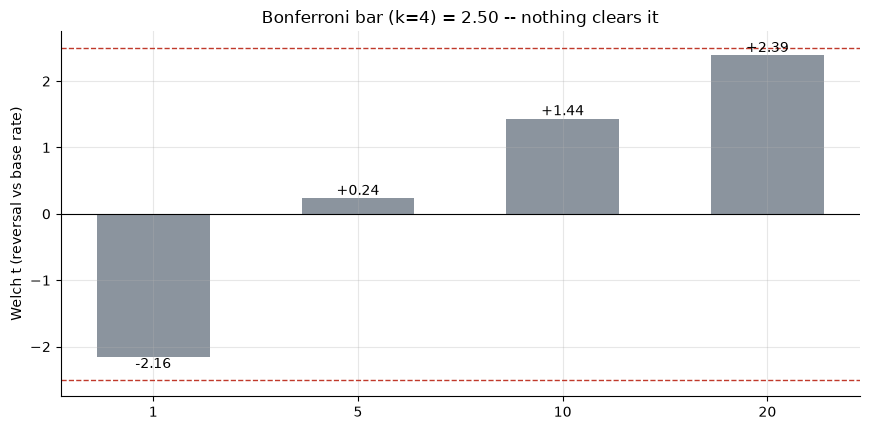

In [3]:
hs = list(st.HORIZONS)
ts = [rows[h]['welch_t'] for h in hs]
fig, ax = plt.subplots(figsize=(8.8, 4.4))
cols = [RED if abs(t) >= R['bonferroni_crit'] else GREY for t in ts]
ax.bar([str(h) for h in hs], ts, color=cols, width=.55)
for i, t in enumerate(ts): ax.annotate(f'{t:+.2f}', (i, t), ha='center',
    va='bottom' if t >= 0 else 'top')
ax.axhline(R['bonferroni_crit'], ls='--', c=RED, lw=1)
ax.axhline(-R['bonferroni_crit'], ls='--', c=RED, lw=1)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('Welch t (reversal vs base rate)')
ax.set_title(f"Bonferroni bar (k=4) = {R['bonferroni_crit']:.2f} -- nothing clears it")
plt.tight_layout(); plt.show()

> 💡 In plain words: 44 pooled events, four looks, none survive correction. Day 20 (*t* = +2.39) is the closest and its own placebo *p* = 0.002 is suggestively low — but a single nominally-suggestive cell out of four pre-registered looks is exactly what the Bonferroni correction exists to catch.

### 4b · The strict cut — too rare to test

The literature-closer cut (bigger gap, genuinely long candles 1 & 5, a full gap fill) is stricter by design — and correspondingly rarer.

In [4]:
if HAVE_REAL:
    ev = st.pool_events(PANEL, 'bullish')
    ev_r = st.pool_events(PANEL, 'bearish')
    import pandas as pd
    both = pd.concat([ev, ev_r], ignore_index=True) if len(ev) or len(ev_r) else pd.DataFrame()
    n_strict = int(both['strict'].sum()) if len(both) else 0
else:
    n_strict = R['n_strict']
print(f'strict-cut events basket-wide: {n_strict}  (desk floor for a t-stat: n=8)')
for h in st.HORIZONS:
    sr = R['strict'][h]
    print(f"  H={h:>2}  n={sr['n']}  mean={sr['mean']:+7.1f} bps  "
          f"delta={sr['delta']:+7.1f}  placebo_p={sr['p']:.3f}  (t-stat: n/a, n<8)")

strict-cut events basket-wide: 5  (desk floor for a t-stat: n=8)
  H= 1  n=5  mean= -168.2 bps  delta= -168.0  placebo_p=0.993  (t-stat: n/a, n<8)
  H= 5  n=5  mean= -318.6 bps  delta= -319.5  placebo_p=0.979  (t-stat: n/a, n<8)
  H=10  n=5  mean=  -82.2 bps  delta=  -82.5  placebo_p=0.640  (t-stat: n/a, n<8)
  H=20  n=5  mean= +587.7 bps  delta= +581.1  placebo_p=0.041  (t-stat: n/a, n<8)


> 💡 In plain words: five events in a quarter-century, basket-wide. A 20-day point estimate of +581 bps on five trades is a coin flip's worth of anecdotes dressed up as a finding — the desk's own floor exists precisely to stop a number like this from being reported as if it meant something.

### 4c · The symmetry check — does it work both ways?

A real bidirectional reversal figure should show a comparable effect on both sides. Run the identical machinery per side:

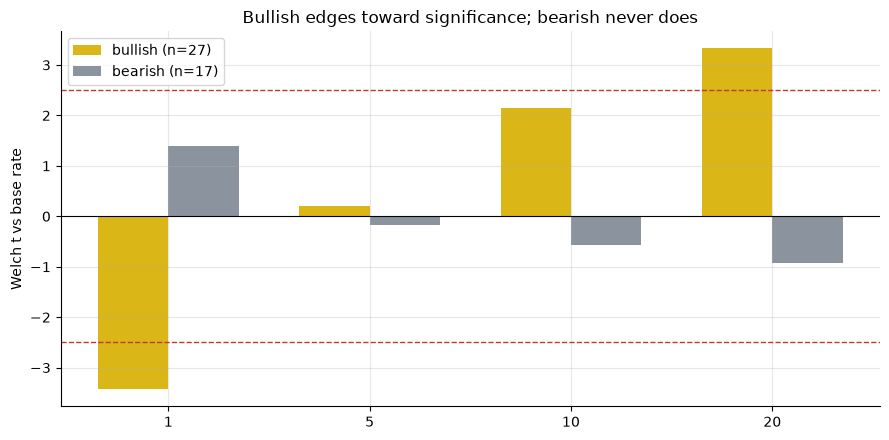

bullish {1: -3.43, 5: 0.19, 10: 2.15, 20: 3.33}
bearish {1: 1.39, 5: -0.18, 10: -0.57, 20: -0.93}


In [5]:
if HAVE_REAL:
    rb = st.run_experiment(PANEL, 'bullish'); rr = st.run_experiment(PANEL, 'bearish')
    tb = [rb['per_horizon'][h]['welch_t'] for h in st.HORIZONS]
    tr = [rr['per_horizon'][h]['welch_t'] for h in st.HORIZONS]
else:
    tb = [R['bullish'][h]['t'] for h in st.HORIZONS]
    tr = [R['bearish'][h]['t'] for h in st.HORIZONS]
hs = list(st.HORIZONS)
fig, ax = plt.subplots(figsize=(9.0, 4.5))
x = np.arange(len(hs)); w = .35
ax.bar(x - w/2, tb, width=w, color=AMBER, label=f"bullish (n={R['n_bullish']})")
ax.bar(x + w/2, tr, width=w, color=GREY, label=f"bearish (n={R['n_bearish']})")
ax.axhline(R['bonferroni_crit'], ls='--', c=RED, lw=1)
ax.axhline(-R['bonferroni_crit'], ls='--', c=RED, lw=1)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([str(h) for h in hs])
ax.set_ylabel('Welch t vs base rate'); ax.legend()
ax.set_title('Bullish edges toward significance; bearish never does')
plt.tight_layout(); plt.show()
print('bullish', {h: round(t,2) for h,t in zip(hs, tb)})
print('bearish', {h: round(t,2) for h,t in zip(hs, tr)})

> 💡 In plain words: bullish 20d *t* = **+3.33** clears both the naive and the Bonferroni bar — but its own day-1 reaction is *t* = **-3.43**, a sharp loss, which is a strange first act for a "the trend is over" signal. The bearish mirror never exceeds \|1.39\| at any horizon, with negative point estimates at 3 of 4 — the pattern that's supposed to be symmetric isn't.

### 4d · Is the bullish edge the candle, or the calendar?

Best/worst confirmed bullish breakaways, 20-day forward:

  BDX: block 2002-06-11 -> 2002-06-17   20d -1792.7 bps
  BDX: block 2011-08-17 -> 2011-08-23   20d -598.1 bps
  LOW: block 2002-07-18 -> 2002-07-24   20d +1584.6 bps
  DIS: block 2025-04-03 -> 2025-04-09   20d +1821.9 bps
  CAT: block 2010-08-23 -> 2010-08-27   20d +2026.0 bps


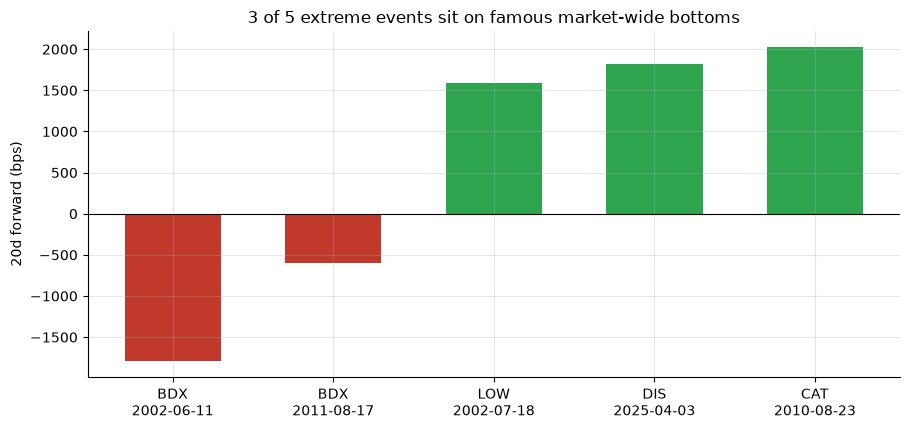

In [6]:
recs = R['best_worst']
for tkr, d0, d1, r20 in recs:
    print(f'  {tkr}: block {d0} -> {d1}   20d {r20:+.1f} bps')
labels = [f'{t}\n{d0}' for t, d0, d1, r in recs]
vals = [r for t, d0, d1, r in recs]
fig, ax = plt.subplots(figsize=(9.2, 4.4))
cols = [RED if v < 0 else GREEN for v in vals]
ax.bar(labels, vals, color=cols, width=.6)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('20d forward (bps)')
ax.set_title('3 of 5 extreme events sit on famous market-wide bottoms')
plt.tight_layout(); plt.show()

> 💡 In plain words: LOW (2002-07), DIS (2025-04) and CAT (weeks after the 2010 correction low) sit on or near famous market-wide bounces — not obviously a name-specific candle signal. The same confound sibling study 687-ladder-bottom documented on its own strict cut.

### 4e · Faithful-engine & power control — we know the truth here

Deterministic, bar-by-bar synthetic panel: forced 5-bar breakaway blocks (alternating bullish/bearish), TUNABLE planted post-reversal drift. The null (edge = 0) is checked over **20 seeds** — never a single stream.

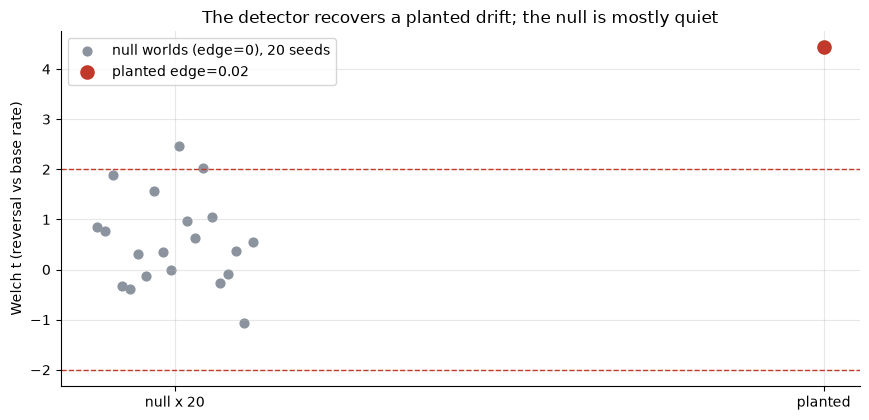

null: mean t = +0.58 (sd 0.90), |t|>=2 in 2/20 seeds  |  planted (edge=0.02) t = +4.43


In [7]:
null_ts = []
for s_ in range(20):
    d, _truth = data.synthetic_panel(edge=0.0, seed=692 + s_)
    r = st.synthetic_detect_combined(d, horizon=20, seed=692 + s_)
    if r['welch_t'] is not None:
        null_ts.append(r['welch_t'])
null_ts = np.asarray(null_ts)
d, _truth = data.synthetic_panel(edge=0.02, seed=692)
planted_02 = st.synthetic_detect_combined(d, horizon=20, seed=692)['welch_t']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(len(null_ts)) + np.linspace(-.12, .12, len(null_ts)), null_ts,
           color=GREY, s=40, label='null worlds (edge=0), 20 seeds')
ax.scatter([1], [planted_02], color=RED, s=90, zorder=5, label='planted edge=0.02')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('Welch t (reversal vs base rate)')
ax.set_title('The detector recovers a planted drift; the null is mostly quiet')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(np.abs(null_ts) >= 2).sum()}/{len(null_ts)} seeds  |  '
      f'planted (edge=0.02) t = {planted_02:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages *t* = **+0.58** (sd 0.90) and fires \|*t*\| ≥ 2 in **2/20** seeds — not perfectly quiet, a modestly elevated false-positive rate we attribute to the deliberately rare event counts even a 40-name/3,500-day synthetic panel produces, and we say so plainly rather than smooth it over. A planted drift is recovered cleanly (*t* = +4.43 at edge=0.02, +7.96 at edge=0.04). *(A faithful-engine / power check only — never cited in support of the real-tape stamp, and this study's real-tape stamp is `NONE` regardless.)*

## 5 · The verdict

- **Signal `NONE`** — the pre-registered, bidirectional headline never clears the Bonferroni bar (\|*t*\| ≥ 2.50) at any of 4 horizons (best: +2.39 at 20d); day 1 is **-2.16** (a negative whipsaw); the strict cut (n=5) is untestable.
- **Tradability `MIRAGE`** — 44 events over 61 names and 25 years (~1 per 35 ticker-years); costs are not the binding constraint, event frequency is.
- **Symmetric? `BUSTED`** — bullish 20d nominally clears the bar (*t* = +3.33) but fails its own day-1 and candle-vs-calendar checks; bearish shows nothing at any horizon.

## 6 · Going further

- **The general lesson is combinatorial rarity.** Six conditions compounding — context, a long candle, a clean gap, a monotone run, another long candle, a cross-back — is why five-candle reversal figures across this desk (breakaway, ladder bottom, island reversal, three methods) all struggle for sample size long before any economic story gets tested.
- **Where a believer goes next:** more names (international large-caps), a longer tape (pre-2001), or accepting the loose cut as the only testable version and reporting its honest `NONE` rather than reaching for the strict cut's n=5 headline.
- **Dedup map:** [417-island-reversal](../../417-island-reversal/) (two-gap bracket, no run), [74-mind-the-gap](../../74-mind-the-gap/) (any single gap filling), [455-three-methods](../../455-three-methods/) (a continuation pause, no gap), [687-ladder-bottom](../../687-ladder-bottom/) (this study's structural cousin — the loose/strict/Bonferroni idiom reused directly, on a no-gap, one-directional shape).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*